In [ ]:
from google.colab import files

uploaded = files.upload()

Saving P2 dataset.zip to P2 dataset.zip


In [ ]:
import zipfile

zip_file = "P2 dataset.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("house_prices_dataset")

In [ ]:
import os

os.listdir("house_prices_dataset")

['P2 dataset']

In [ ]:
import os

os.listdir("house_prices_dataset/P2 dataset")

['train (1).csv',
 'test (1).csv',
 'sample_submission (1).csv',
 'data_description.txt']

In [ ]:
import os

os.rename(
    "house_prices_dataset/P2 dataset/train (1).csv",
    "house_prices_dataset/P2 dataset/train.csv"
)

os.rename(
    "house_prices_dataset/P2 dataset/test (1).csv",
    "house_prices_dataset/P2 dataset/test.csv"
)

os.rename(
    "house_prices_dataset/P2 dataset/sample_submission (1).csv",
    "house_prices_dataset/P2 dataset/sample_submission.csv"
)

In [ ]:
# ==========================================================
# HOUSE PRICE PREDICTION PROJECT
# STEP 1 : IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

# Install catboost if not already installed
!pip install catboost

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Models
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
# ===============================
# STEP 2 : Load Dataset
# ===============================

# Load training and testing datasets
train = pd.read_csv("house_prices_dataset/P2 dataset/train.csv")
test = pd.read_csv("house_prices_dataset/P2 dataset/test.csv")

# Save test IDs for final submission
test_ids = test["Id"]

# Display dataset shapes
print("Training Dataset Shape :", train.shape)
print("Testing Dataset Shape  :", test.shape)

# Display first 5 rows
print("\nTraining Dataset Preview")
display(train.head())

print("\nTesting Dataset Preview")
display(test.head())

Training Dataset Shape : (1460, 81)
Testing Dataset Shape  : (1459, 80)

Training Dataset Preview


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Testing Dataset Preview


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [ ]:
# ===============================
# STEP 3 : Dataset Information & EDA
# ===============================

print("="*60)
print("TRAIN DATASET INFORMATION")
print("="*60)

train.info()

print("\n" + "="*60)
print("TEST DATASET INFORMATION")
print("="*60)

test.info()

# -----------------------------
# Check Missing Values
# -----------------------------
print("\nMissing Values in Train Dataset")
missing_train = train.isnull().sum().sort_values(ascending=False)
missing_train = missing_train[missing_train > 0]
display(missing_train)

print("\nMissing Values in Test Dataset")
missing_test = test.isnull().sum().sort_values(ascending=False)
missing_test = missing_test[missing_test > 0]
display(missing_test)

# -----------------------------
# Statistical Summary
# -----------------------------
print("\nNumerical Feature Summary")
display(train.describe())

# -----------------------------
# Duplicate Records
# -----------------------------
print("Duplicate Rows in Train :", train.duplicated().sum())
print("Duplicate Rows in Test  :", test.duplicated().sum())

# -----------------------------
# Data Types
# -----------------------------
print("\nCategorical Features :", len(train.select_dtypes(include='object').columns))
print("Numerical Features   :", len(train.select_dtypes(exclude='object').columns))

TRAIN DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-nu

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81



Missing Values in Test Dataset


,0
PoolQC,1456
MiscFeature,1408
Alley,1352
Fence,1169
MasVnrType,894
FireplaceQu,730
LotFrontage,227
GarageYrBlt,78
GarageCond,78
GarageFinish,78



Numerical Feature Summary


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Duplicate Rows in Train : 0
Duplicate Rows in Test  : 0

Categorical Features : 43
Numerical Features   : 38


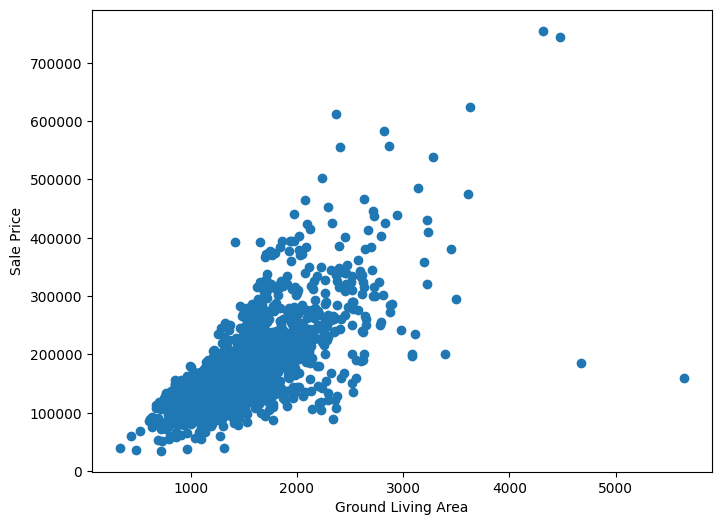

Before removing outliers : (1460, 81)
After removing outliers : (1458, 81)


In [ ]:
# ===============================
# STEP 4.1 : Remove Outliers
# ===============================

plt.figure(figsize=(8,6))

plt.scatter(train["GrLivArea"], train["SalePrice"])

plt.xlabel("Ground Living Area")
plt.ylabel("Sale Price")

plt.show()

print("Before removing outliers :", train.shape)

train = train.drop(
    train[
        (train["GrLivArea"] > 4000) &
        (train["SalePrice"] < 300000)
    ].index
)

print("After removing outliers :", train.shape)

In [ ]:
# ===============================
# STEP 4.2 : Target Transformation
# ===============================

y = np.log1p(train["SalePrice"])

print("Target Shape :", y.shape)
print("Target Mean :", y.mean())

train.drop("SalePrice", axis=1, inplace=True)

Target Shape : (1458,)
Target Mean : 12.024015155682552


In [ ]:
# ===============================
# STEP 4.3 : Combine Train & Test
# ===============================

all_data = pd.concat((train, test)).reset_index(drop=True)

print("Combined Shape :", all_data.shape)

display(all_data.head())

Combined Shape : (2917, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


In [ ]:
# ===============================
# STEP 4.4 : Missing Values
# ===============================

missing = (
    all_data.isnull().sum() /
    len(all_data)
) * 100

missing = missing[missing > 0]

missing = missing.sort_values(ascending=False)

display(missing)

,0
PoolQC,99.691464
MiscFeature,96.400411
Alley,93.212204
Fence,80.425094
MasVnrType,60.541652
FireplaceQu,48.680151
LotFrontage,16.660953
GarageQual,5.450806
GarageYrBlt,5.450806
GarageCond,5.450806


In [ ]:
# ===============================
# STEP 4.5 : Fill Missing Values
# ===============================

# Numerical columns
num_cols = all_data.select_dtypes(exclude="object").columns

for col in num_cols:
    all_data[col] = all_data[col].fillna(all_data[col].median())

# Categorical columns
cat_cols = all_data.select_dtypes(include="object").columns

for col in cat_cols:
    all_data[col] = all_data[col].fillna("None")

print("Remaining Missing Values :", all_data.isnull().sum().sum())

Remaining Missing Values : 0


In [ ]:
# ==========================================================
# Feature Engineering
# ==========================================================

# ===============================
# STEP 5.1 : Convert Numerical Features
# ===============================

all_data["MSSubClass"] = all_data["MSSubClass"].astype(str)
all_data["OverallCond"] = all_data["OverallCond"].astype(str)
all_data["YrSold"] = all_data["YrSold"].astype(str)
all_data["MoSold"] = all_data["MoSold"].astype(str)

print("Converted numerical categorical features.")

Converted numerical categorical features.


In [ ]:
# ===============================
# STEP 5.2 : Label Encoding
# ===============================

from sklearn.preprocessing import LabelEncoder

# Select all categorical columns
categorical_cols = all_data.select_dtypes(include=["object"]).columns

# Apply Label Encoding
encoder = LabelEncoder()

for col in categorical_cols:
    all_data[col] = encoder.fit_transform(all_data[col])

print("Label Encoding Completed Successfully!")

print("Dataset Shape :", all_data.shape)

Label Encoding Completed Successfully!
Dataset Shape : (2917, 80)


In [ ]:
# ===============================
# STEP 5.3 : Feature Engineering
# ===============================

# Create Total Square Feet feature
all_data["TotalSF"] = (
    all_data["TotalBsmtSF"] +
    all_data["1stFlrSF"] +
    all_data["2ndFlrSF"]
)

print("TotalSF Feature Created Successfully!")

# Display first 5 rows
display(
    all_data[
        ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "TotalSF"]
    ].head()
)

TotalSF Feature Created Successfully!


,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF
0,856.0,856,854,2566.0
1,1262.0,1262,0,2524.0
2,920.0,920,866,2706.0
3,756.0,961,756,2473.0
4,1145.0,1145,1053,3343.0


In [ ]:
# ===============================
# STEP 5.4 : Reduce Skewness
# ===============================

from scipy.stats import skew
from scipy.special import boxcox1p

# Select numerical features
numeric_features = all_data.select_dtypes(include=[np.number]).columns

# Calculate skewness
skewness = all_data[numeric_features].apply(lambda x: skew(x.dropna()))

# Select highly skewed features
skewed_features = skewness[abs(skewness) > 0.75]

print("Number of Skewed Features:", len(skewed_features))

# Apply Box-Cox transformation
for feature in skewed_features.index:
    all_data[feature] = boxcox1p(all_data[feature], 0.15)

print("Skewness Correction Completed Successfully!")

# Display first few skewed features
display(skewed_features.sort_values(ascending=False).head(10))

Number of Skewed Features: 48
Skewness Correction Completed Successfully!


,0
Utilities,33.961811
MiscVal,21.939672
PoolArea,17.688664
LotArea,13.109495
Condition2,12.340989
LowQualFinSF,12.084539
Heating,12.074570
3SsnPorch,11.372080
RoofMatl,8.722755
MiscFeature,5.062388


In [ ]:
# ===============================
# STEP 6 : Split Train and Test Data
# ===============================

# Split the combined dataset back into train and test
X_train = all_data.iloc[:len(y), :]
X_test = all_data.iloc[len(y):, :]

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Target Shape            :", y.shape)

Training Features Shape : (1458, 81)
Testing Features Shape  : (1459, 81)
Target Shape            : (1458,)


In [ ]:
# ===============================
# STEP 6.1 : Train-Test Split
# ===============================

from sklearn.model_selection import train_test_split

X_train_split, X_valid, y_train_split, y_valid = train_test_split(
    X_train,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set Shape   :", X_train_split.shape)
print("Validation Set Shape :", X_valid.shape)
print("Training Labels Shape:", y_train_split.shape)
print("Validation Labels Shape:", y_valid.shape)

Training Set Shape   : (1166, 81)
Validation Set Shape : (292, 81)
Training Labels Shape: (1166,)
Validation Labels Shape: (292,)


In [ ]:
# ===============================
# STEP 7 : Ridge Regression Model
# ===============================

from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

# Create the model
ridge_model = Ridge(alpha=10)

# Train the model
ridge_model.fit(X_train_split, y_train_split)

# Predict on validation set
ridge_pred = ridge_model.predict(X_valid)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_valid, ridge_pred))
mae = mean_absolute_error(y_valid, ridge_pred)
r2 = r2_score(y_valid, ridge_pred)

print("===== Ridge Regression Results =====")
print("RMSE :", round(rmse, 5))
print("MAE  :", round(mae, 5))
print("R² Score :", round(r2, 5))

===== Ridge Regression Results =====
RMSE : 0.1186
MAE  : 0.08318
R² Score : 0.91656


In [ ]:
# ===============================
# STEP 8 : Random Forest Regressor
# ===============================

from sklearn.ensemble import RandomForestRegressor

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_split, y_train_split)

# Predict
rf_pred = rf_model.predict(X_valid)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_valid, rf_pred))
mae = mean_absolute_error(y_valid, rf_pred)
r2 = r2_score(y_valid, rf_pred)

print("===== Random Forest Results =====")
print("RMSE :", round(rmse,5))
print("MAE  :", round(mae,5))
print("R² Score :", round(r2,5))

===== Random Forest Results =====
RMSE : 0.14328
MAE  : 0.09681
R² Score : 0.87822


In [ ]:
# ===============================
# STEP 9 : XGBoost Regressor
# ===============================

from xgboost import XGBRegressor

# Create the model
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

# Train the model
xgb_model.fit(X_train_split, y_train_split)

# Predict
xgb_pred = xgb_model.predict(X_valid)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_valid, xgb_pred))
mae = mean_absolute_error(y_valid, xgb_pred)
r2 = r2_score(y_valid, xgb_pred)

print("===== XGBoost Results =====")
print("RMSE :", round(rmse, 5))
print("MAE  :", round(mae, 5))
print("R² Score :", round(r2, 5))

===== XGBoost Results =====
RMSE : 0.11811
MAE  : 0.07952
R² Score : 0.91725


In [ ]:
# ===============================
# STEP 10 : LightGBM Regressor
# ===============================

from lightgbm import LGBMRegressor

# Create the model
lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

# Train the model
lgb_model.fit(X_train_split, y_train_split)

# Predict
lgb_pred = lgb_model.predict(X_valid)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_valid, lgb_pred))
mae = mean_absolute_error(y_valid, lgb_pred)
r2 = r2_score(y_valid, lgb_pred)

print("===== LightGBM Results =====")
print("RMSE :", round(rmse, 5))
print("MAE  :", round(mae, 5))
print("R² Score :", round(r2, 5))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003943 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3617
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 74
[LightGBM] [Info] Start training from score 12.023362
===== LightGBM Results =====
RMSE : 0.13545
MAE  : 0.08882
R² Score : 0.89116


In [ ]:
# ===============================
# STEP 11 : CatBoost Regressor
# ===============================

from catboost import CatBoostRegressor

# Create the model
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

# Train the model
cat_model.fit(X_train_split, y_train_split)

# Predict
cat_pred = cat_model.predict(X_valid)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_valid, cat_pred))
mae = mean_absolute_error(y_valid, cat_pred)
r2 = r2_score(y_valid, cat_pred)

print("===== CatBoost Results =====")
print("RMSE :", round(rmse, 5))
print("MAE  :", round(mae, 5))
print("R² Score :", round(r2, 5))

===== CatBoost Results =====
RMSE : 0.11597
MAE  : 0.0791
R² Score : 0.92022


In [ ]:
# ===============================
# STEP 12 : Train Best Model
# ===============================

best_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

best_model.fit(X_train, y)

print("Best Model Trained Successfully!")

Best Model Trained Successfully!


In [ ]:
# ===============================
# STEP 12.1 : 5-Fold Cross Validation
# ===============================

from sklearn.model_selection import KFold, cross_val_score
import numpy as np

cv_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = -cross_val_score(
    cv_model,
    X_train,
    y,
    scoring="neg_root_mean_squared_error",
    cv=kfold,
    n_jobs=-1
)

print("Cross Validation RMSE Scores:")
print(cv_scores)

print("\nCV RMSE Mean :", round(cv_scores.mean(),5))
print("CV RMSE Std  :", round(cv_scores.std(),5))

Cross Validation RMSE Scores:
[0.11721086 0.10792737 0.11978634 0.12263662 0.10307592]

CV RMSE Mean : 0.11413
CV RMSE Std  : 0.00741


In [ ]:
# ===============================
# STEP 13 : Generate Submission
# ===============================

# Predict log-transformed prices
predictions = best_model.predict(X_test)

# Convert back to original prices
predictions = np.expm1(predictions)

# Create submission file
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": predictions
})

submission.to_csv("submission.csv", index=False)

print(submission.head())
print("\nsubmission.csv created successfully!")

     Id      SalePrice
0  1461  122149.390114
1  1462  164059.132381
2  1463  183313.219575
3  1464  193468.842414
4  1465  177359.822346

submission.csv created successfully!


In [ ]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         1459 non-null   int64  
 1   SalePrice  1459 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 22.9 KB


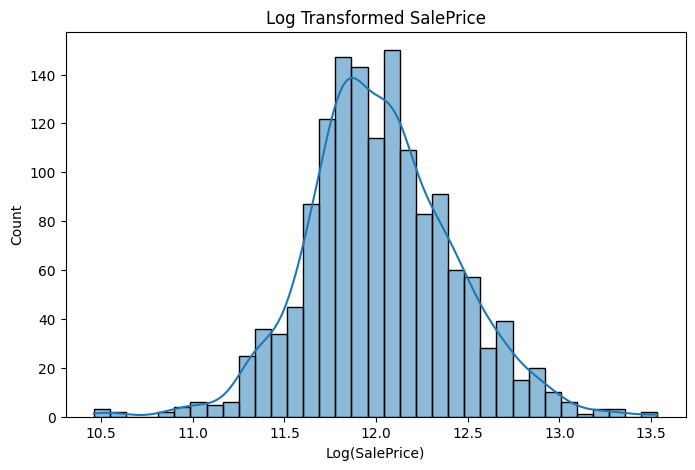

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(y, kde=True)
plt.title("Log Transformed SalePrice")
plt.xlabel("Log(SalePrice)")
plt.show()

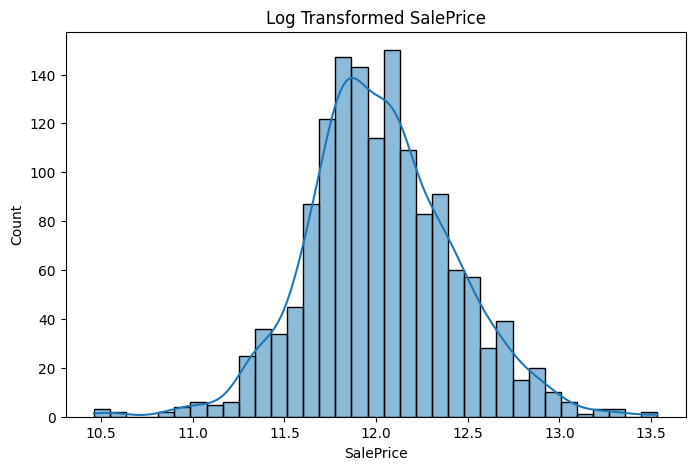

In [ ]:
#Target Distribution (After Log Transform)
plt.figure(figsize=(8,5))
sns.histplot(y, kde=True)
plt.title("Log Transformed SalePrice")
plt.show()

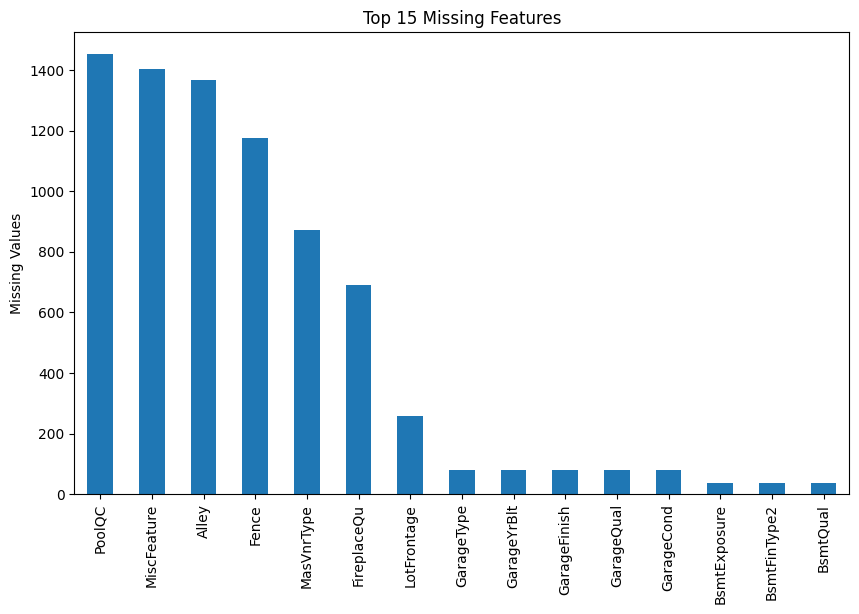

In [ ]:
#Missing Values
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing.head(15).plot(kind="bar")
plt.title("Top 15 Missing Features")
plt.ylabel("Missing Values")
plt.show()

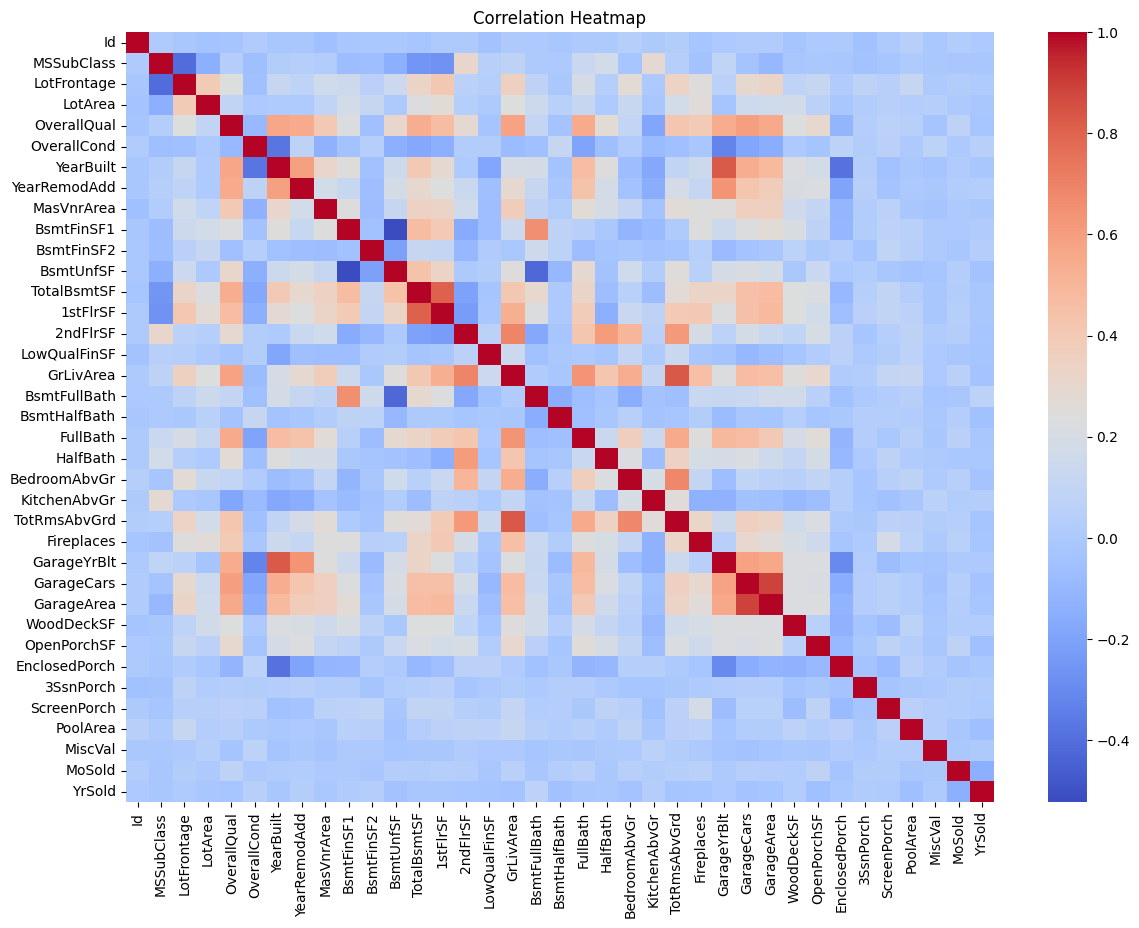

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(14,10))
corr = train.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

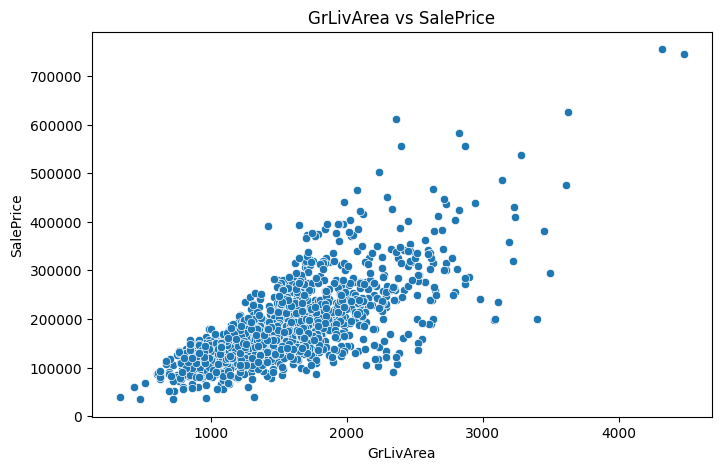

In [ ]:
#SalePrice vs GrLivArea (Outlier Detection)
plt.figure(figsize=(8,5))
sns.scatterplot(x=train["GrLivArea"], y=np.expm1(y))
plt.title("GrLivArea vs SalePrice")
plt.show()

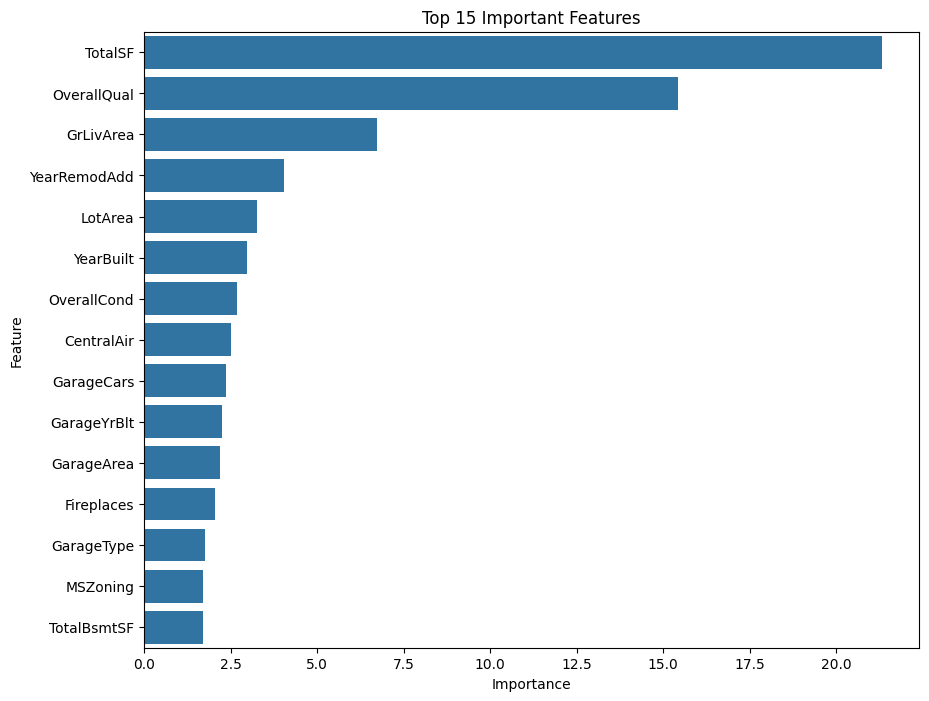

In [ ]:
#Feature Importance (CatBoost)
importance = best_model.get_feature_importance()

feature_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(
    data=feature_imp.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Important Features")
plt.show()

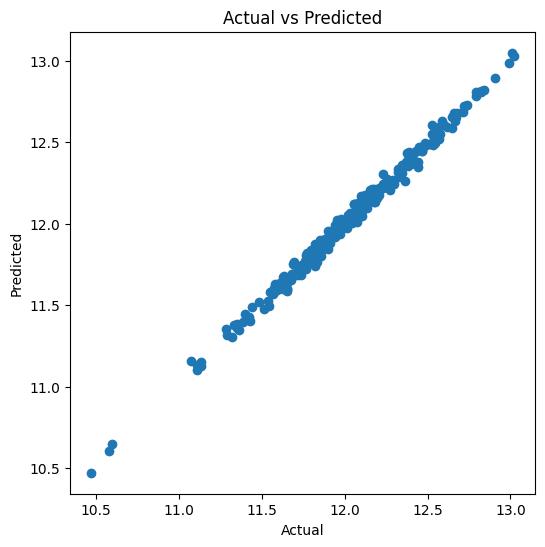

In [ ]:
#Actual vs Predicted
pred = best_model.predict(X_valid)

plt.figure(figsize=(6,6))
plt.scatter(y_valid, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

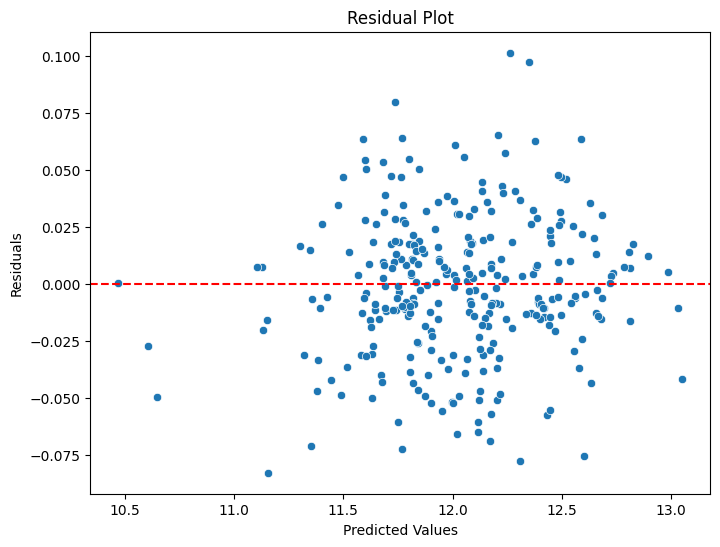

In [82]:
residuals = y_valid - pred

plt.figure(figsize=(8,6))
sns.scatterplot(x=pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()